In [1]:
from pathlib import Path

from maite_datasets.object_detection import SkySeaLand

data_root = Path("./data")

# One ~262 MB download into ./data/skysealand, shared by all three exports below.
# A re-run reads what is already on disk instead of downloading again.
SkySeaLand(root=data_root, image_set="base", download=True)

split_paths = {name: data_root / f"skysealand_datamaite_{name}" for name in ("train", "val", "test")}
for image_set in split_paths:
    SkySeaLand(root=data_root, image_set=image_set, as_datamaite=True)

print("\n".join(f"{name}: {path}" for name, path in split_paths.items()))

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train: data/skysealand_datamaite_train
val: data/skysealand_datamaite_val
test: data/skysealand_datamaite_test


In [2]:
from dataeval.config import set_max_processes

from dataeval_flow import run_task
from dataeval_flow.config import (
    CocoDatasetConfig,
    MetadataPolicyConfig,
    PipelineConfig,
    SourceConfig,
    TaskConfig,
    ViewConfig,
    ViewOperation,
)
from dataeval_flow.config.extractors import BoVWExtractorConfig
from dataeval_flow.workflows.audit import AuditConfig

# Limit concurrency to 4 processes for memory management during image decoding.
set_max_processes(4)

audit_workflow = AuditConfig(
    name="skysealand_audit",
    outliers={"flags": ["dimension", "pixel", "visual"], "outlier_threshold": ["adaptive", 4.0]},
    metadata="skysealand_factors",
)

task = TaskConfig(
    name="skysealand-audit",
    workflow="skysealand_audit",
    sources=["train", "val", "test"],
    extractor="bovw_ext",
)

config = PipelineConfig(
    max_processes=2,
    seed=0,
    metadata=[
        MetadataPolicyConfig(
            name="skysealand_factors",
            # Image statistics evaluated as factors
            intrinsic_factors=["visual", "pixel"],
            # Exclude constant metadata fields
            exclude=["label_file_exists"],
            # Shared encoding reference for cross-split factor comparability
            reference_split="train",
        )
    ],
    datasets=[CocoDatasetConfig(name=f"skysealand_{name}", path=str(path)) for name, path in split_paths.items()],
    views=[
        ViewConfig(
            name="sample300",
            operations=[
                ViewOperation(type="Shuffle", params={"seed": 0}),
                ViewOperation(type="Limit", params={"size": 300}),
            ],
        ),
    ],
    sources=[
        SourceConfig(name="train", dataset="skysealand_train", view="sample300"),
        SourceConfig(name="val", dataset="skysealand_val"),
        SourceConfig(name="test", dataset="skysealand_test"),
    ],
    extractors=[BoVWExtractorConfig(name="bovw_ext", vocab_size=512, batch_size=32)],
    workflows=[audit_workflow],
    tasks=[task],
)

print("Configuration ready:")
print(f"  Workflow:   {audit_workflow.name} (type={audit_workflow.type})")
print(f"  Task:       {task.name} -> {task.workflow}")
print(f"  Sources:    {task.sources}")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Configuration ready:
  Workflow:   skysealand_audit (type=audit)
  Task:       skysealand-audit -> skysealand_audit
  Sources:    ['train', 'val', 'test']


In [3]:
result = run_task(config, task, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_binning.py:151: UserWarning: `height`, `instance_brightness`, `instance_contrast`, `instance_darkness`, `instance_entropy`, `instance_kurtosis`, `instance_mean`, `instance_sharpness`, `instance_skew`, `instance_std`, `instance_var`, `instance_zeros`, `num_annotations`, `unit_brightness`, `unit_contrast`, `unit_darkness`, `unit_entropy`, `unit_kurtosis`, `unit_mean`, `unit_sharpness`, `unit_skew`, `unit_std`, `unit_var`, `unit_zeros` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  export(path)


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_binning.py:418: UserWarning: Declared cuts left bins unused: instance_kurtosis (37 of 40 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  factor_info = metadata.factor_info


In [4]:
if not result.success:
    print(f"Workflow failed: {result.errors}")
assert result.success

In [5]:
verdict = result.verdict
assert verdict is not None

print(verdict.line())
for item in verdict.blocking + verdict.warnings:
    print(f"  {item.step:<28} {item.title}: {item.brief}")
for item in verdict.not_assessed:
    print(f"  {item.step:<28} not assessed: {item.reason}")

Ready with caveats: 11 warnings
  image-outliers-train         Image Outliers: 17 images (5.7%)
  image-outliers-evals[val]    Image Outliers: 10 images (7.6%)
  image-outliers-evals[test]   Image Outliers: 10 images (7.9%)
  factor-issues-train          Unreadable factors: 6 factors
  factor-issues-evals[val]     Unreadable factors: 6 factors
  factor-issues-evals[test]    Unreadable factors: 6 factors
  class-stratification[val]    Class Stratification: max deviation 17.2pp (class 'boat' in evals[val])
  class-coverage               Class Coverage: 41 uncovered (1.0%) · 2 one-dimensional
  dimensional-completeness     Dimensional Completeness: Completeness: 0.038
  shortcut-risk                Shortcut Risk: 22 of 27 factors tied to the class: unit_mean (MI=0.88), unit_skew (MI=0.87), unit_std (MI=0.86)
  factor-coverage-gaps         Factor Coverage Gaps: 1952 gaps identified


17 flagged frames in train's sample


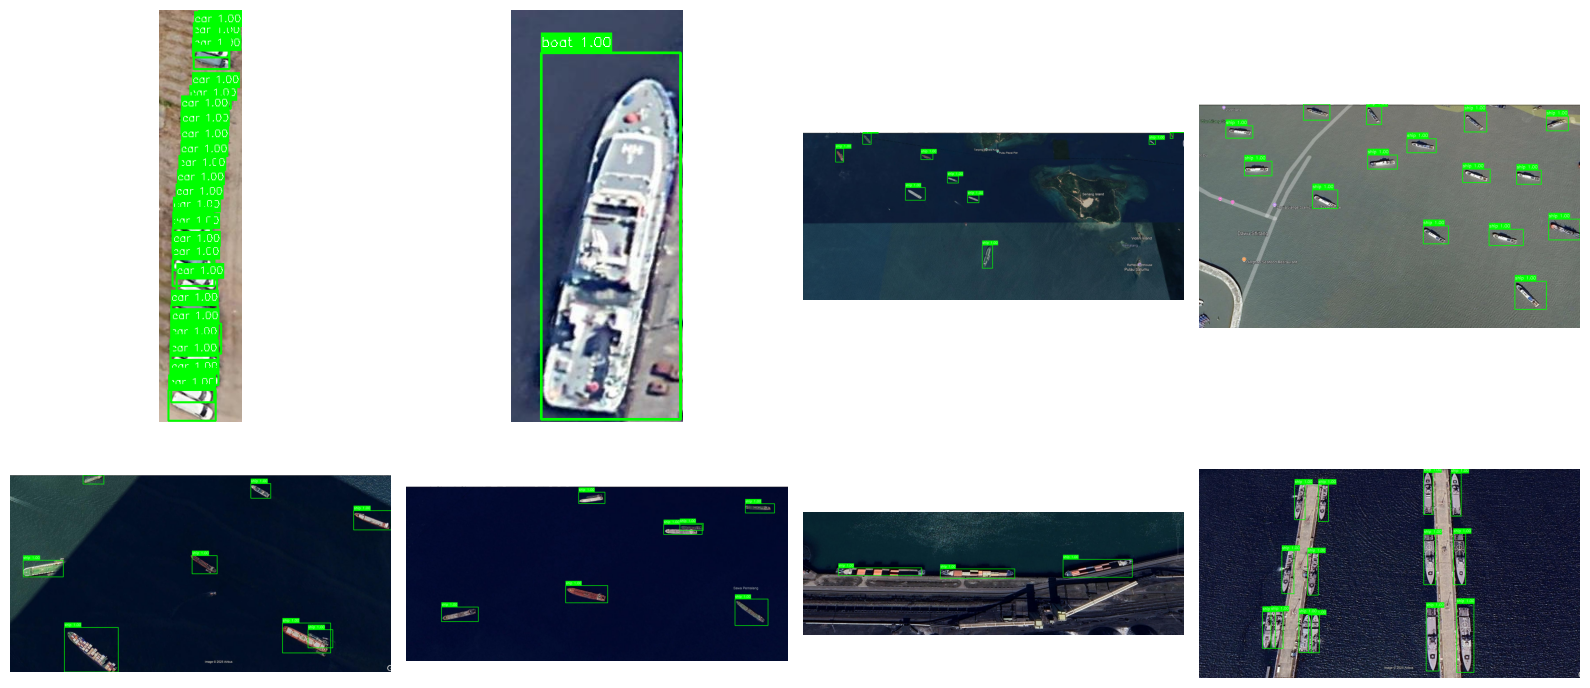

In [6]:
from dataeval_plots import plot

flags = result.steps["outliers-train"].output.data()  # one row per flagged image and statistic
flagged = sorted(set(flags["item_index"].to_list()))
print(f"{len(flagged)} flagged frames in train's sample")

assert result.sources is not None
_ = plot(result.sources["train"], indices=flagged[:8], images_per_row=4, figsize=(16, 8))

In [7]:
audit_workflow = AuditConfig(
    name="skysealand_audit",
    outliers={"flags": ["dimension", "pixel", "visual"], "outlier_threshold": ["adaptive", 4.0]},
    metadata="skysealand_factors",
    accepted={"image-outliers": "Narrow crops and dark open-water scenes, normal for this imagery; none is corrupt."},
)
config = config.model_copy(update={"workflows": [audit_workflow]})

result = run_task(config, task, cache_dir=Path("./cache"))
verdict = result.verdict
assert verdict is not None

print(verdict.line())
for acceptance in verdict.accepted:
    print(f"  {acceptance.check} ({acceptance.state}): {acceptance.reason}")

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_binning.py:151: UserWarning: `height`, `instance_brightness`, `instance_contrast`, `instance_darkness`, `instance_entropy`, `instance_kurtosis`, `instance_mean`, `instance_sharpness`, `instance_skew`, `instance_std`, `instance_var`, `instance_zeros`, `num_annotations`, `unit_brightness`, `unit_contrast`, `unit_darkness`, `unit_entropy`, `unit_kurtosis`, `unit_mean`, `unit_sharpness`, `unit_skew`, `unit_std`, `unit_var`, `unit_zeros` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  export(path)


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_binning.py:418: UserWarning: Declared cuts left bins unused: instance_kurtosis (37 of 40 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  factor_info = metadata.factor_info


Ready with caveats: 8 warnings, 1 accepted risk
  image-outliers (warned): Narrow crops and dark open-water scenes, normal for this imagery; none is corrupt.


In [8]:
print(result.report(detailed=False))


  AUDIT
  Workflow:  skysealand_audit (audit)
  Timestamp: 2026-10-09T07:13:05.529877+00:00
  Duration:  33.63s
  Source:    train (skysealand_train[sample300])
             val (skysealand_val)
             test (skysealand_test)
  Model:     bovw_ext (bovw)

  Verdict: Ready with caveats: 8 warnings, 1 accepted risk  [..]

  WHAT WAS AUDITED
                    train               val                  test
  ----------------  ------------------  -------------------  -------------------
  Source            train               val                  test
                    (skysealand_train[  (skysealand_val)     (skysealand_test)
                    sample300])

  Items             300                 132                  127

  Labels            4,181               1,992                2,075

  Empty images      0                   0                    0

  Classes           4: airplane, boat,  4: airplane, boat,   4: airplane, boat,
                    car, ship           car, ship 

In [9]:
from dataeval_flow import dataset_digest, load_dataset

recorded = {"train": result.steps["content-digest-train"].output.data()}
for name, step in (result.steps["content-digest-evals"].elements or {}).items():
    recorded[name] = step.output.data()

for name, record in recorded.items():
    print(f"{name:<5} {record['items']:>4} items  {record['content']}")

sample = dataset_digest(result.sources["train"])  # the 300 frames the view selects
whole = dataset_digest(load_dataset(split_paths["train"], dataset_format="coco"))  # all 1,048 frames

print(f"\ntrain's view matches the record:  {sample.content == recorded['train']['content']}")
print(f"the whole train split matches it: {whole.content == recorded['train']['content']}")

train  300 items  6aea278e9c054550ac58859c37f9752652124eb1d870ef34c4f04b8afda2993f
val    132 items  ac2f5a60bca18ec93d4168df9bcb3a3dd828a035380c8bba750df81d12b63946
test   127 items  47ce59be5fefaa503f58b32195d36e4836ed4d42b6985365bc19992f6f657ea0



train's view matches the record:  True
the whole train split matches it: False


In [10]:
import json

envelope = json.loads(result.export(fmt="json"))

print(f"Verdict:        {envelope['verdict']['level']}")
print(f"Accepted:       {[acceptance['check'] for acceptance in envelope['verdict']['accepted']]}")
print(f"Train's digest: {envelope['steps']['content-digest-train']['output']['data']['content']}")

Verdict:        ready-with-caveats
Accepted:       ['image-outliers']
Train's digest: 6aea278e9c054550ac58859c37f9752652124eb1d870ef34c4f04b8afda2993f
